# Figure 2: characterization of indexed perturbation evidence

Resource scale, direct cell–perturbation coverage, cell-line lineage, and related-context signature similarity.

## Resource scale

In [ ]:

from pathlib import Path
import sys, json, math, textwrap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

TASK = Path('/Users/dudu/Documents/3_Project/12_PxFquery/5_phase_translation/G-011_paper_figure_planning/T-145_figure2_data_and_notebook_figure_workbench')
RESOURCE = Path('/Users/dudu/.cache/pxfquery/resources/v20260628')
PKG_SRC = Path('/Users/dudu/Documents/3_Project/12_PxFquery_github_export/src')
TABLE_DIR = TASK / '4_artifact' / '5_table'
FIG_DIR = TASK / '4_artifact' / '4_picture' / 'figure2'
DOC_DIR = TASK / '4_artifact' / '3_document'
for p in [TABLE_DIR, FIG_DIR, DOC_DIR]:
    p.mkdir(parents=True, exist_ok=True)
if str(PKG_SRC) not in sys.path:
    sys.path.insert(0, str(PKG_SRC))
plt.rcParams.update({
    'font.size': 9,
    'axes.titlesize': 11,
    'axes.labelsize': 9,
    'figure.dpi': 160,
    'savefig.dpi': 300,
    'pdf.fonttype': 42,
    'ps.fonttype': 42,
})
MODALITIES = ['cp', 'sh', 'xpr']

def load_obs(modality):
    return pd.read_parquet(RESOURCE / f'{modality}_obs_min.parquet').reset_index(drop=True)

def load_var_names(modality):
    return json.loads((RESOURCE / f'{modality}_var_names.json').read_text())

def load_json(name):
    return json.loads((RESOURCE / name).read_text())

def matrix_shape(modality):
    npy = RESOURCE / f'{modality}_X_dense_thr0.1_round2_float16_compressed.npy'
    if npy.exists():
        return tuple(np.load(npy, mmap_mode='r').shape)
    npz = RESOURCE / f'{modality}_X_dense_thr0.1_round2_float16_compressed.npz'
    payload = np.load(npz)
    if 'shape' in payload.files:
        return tuple(payload['shape'])
    if 'X' in payload.files:
        return tuple(payload['X'].shape)
    first = payload.files[0]
    return tuple(payload[first].shape)

def save_figure(fig, stem):
    paths = []
    for ext in ['png', 'svg', 'pdf']:
        path = FIG_DIR / f'{stem}.{ext}'
        fig.savefig(path, bbox_inches='tight')
        paths.append(path)
    return paths


In [ ]:

manifest = json.loads((PKG_SRC / 'pxfquery' / 'resources' / 'manifests' / 'zenodo_21001791_v20260628.json').read_text())
cell_index = load_json('cellline_index.json')
drug_index = load_json('drug_index.json')
gene_index_simple = load_json('gene_index_simple.json')
function_index = load_json('function_index.json')
rows = []
for mod in MODALITIES:
    obs = load_obs(mod)
    var = load_var_names(mod)
    rows.append({
        'modality': mod,
        'n_obs_rows': int(len(obs)),
        'n_var_functions': int(len(var)),
        'n_cell_lines': int(obs['cell_iname'].nunique()),
        'n_perturbations': int(obs['pert_id'].nunique()),
        'n_cmap_names': int(obs['cmap_name'].nunique()),
        'n_observed_cell_perturbation_pairs': int(obs[['cell_iname','pert_id']].drop_duplicates().shape[0]),
        'matrix_shape': 'x'.join(map(str, matrix_shape(mod))),
    })
scale = pd.DataFrame(rows)
scale['resource_pack_version'] = manifest.get('version')
scale['manifest_record_id'] = manifest.get('record_id')
scale['n_index_cell_lines'] = len(cell_index.get('valid_cells', []))
scale['n_drug_alias_entries'] = len(drug_index)
scale['n_gene_index_simple_entries'] = len(gene_index_simple)
scale['n_function_index_var_names'] = len(function_index.get('var_names', []))
out = TABLE_DIR / 'figure2_table_resource_scale.csv'
scale.to_csv(out, index=False)
scale


## Direct coverage

In [ ]:

from pathlib import Path
import sys, json, math, textwrap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

TASK = Path('/Users/dudu/Documents/3_Project/12_PxFquery/5_phase_translation/G-011_paper_figure_planning/T-145_figure2_data_and_notebook_figure_workbench')
RESOURCE = Path('/Users/dudu/.cache/pxfquery/resources/v20260628')
PKG_SRC = Path('/Users/dudu/Documents/3_Project/12_PxFquery_github_export/src')
TABLE_DIR = TASK / '4_artifact' / '5_table'
FIG_DIR = TASK / '4_artifact' / '4_picture' / 'figure2'
DOC_DIR = TASK / '4_artifact' / '3_document'
for p in [TABLE_DIR, FIG_DIR, DOC_DIR]:
    p.mkdir(parents=True, exist_ok=True)
if str(PKG_SRC) not in sys.path:
    sys.path.insert(0, str(PKG_SRC))
plt.rcParams.update({
    'font.size': 9,
    'axes.titlesize': 11,
    'axes.labelsize': 9,
    'figure.dpi': 160,
    'savefig.dpi': 300,
    'pdf.fonttype': 42,
    'ps.fonttype': 42,
})
MODALITIES = ['cp', 'sh', 'xpr']

def load_obs(modality):
    return pd.read_parquet(RESOURCE / f'{modality}_obs_min.parquet').reset_index(drop=True)

def load_var_names(modality):
    return json.loads((RESOURCE / f'{modality}_var_names.json').read_text())

def load_json(name):
    return json.loads((RESOURCE / name).read_text())

def matrix_shape(modality):
    npy = RESOURCE / f'{modality}_X_dense_thr0.1_round2_float16_compressed.npy'
    if npy.exists():
        return tuple(np.load(npy, mmap_mode='r').shape)
    npz = RESOURCE / f'{modality}_X_dense_thr0.1_round2_float16_compressed.npz'
    payload = np.load(npz)
    if 'shape' in payload.files:
        return tuple(payload['shape'])
    if 'X' in payload.files:
        return tuple(payload['X'].shape)
    first = payload.files[0]
    return tuple(payload[first].shape)

def save_figure(fig, stem):
    paths = []
    for ext in ['png', 'svg', 'pdf']:
        path = FIG_DIR / f'{stem}.{ext}'
        fig.savefig(path, bbox_inches='tight')
        paths.append(path)
    return paths


In [ ]:

rows = []
for mod in MODALITIES:
    obs = load_obs(mod)
    n_cells = int(obs['cell_iname'].nunique())
    n_perts = int(obs['pert_id'].nunique())
    observed_pairs = int(obs[['cell_iname','pert_id']].drop_duplicates().shape[0])
    potential_pairs = int(n_cells * n_perts)
    rows.append({
        'modality': mod,
        'n_cells': n_cells,
        'n_perturbations': n_perts,
        'observed_pairs': observed_pairs,
        'potential_pairs': potential_pairs,
        'unobserved_pairs': potential_pairs - observed_pairs,
        'observed_fraction': observed_pairs / potential_pairs if potential_pairs else np.nan,
    })
summary = pd.DataFrame(rows)
total = pd.DataFrame([{
    'modality': 'total_by_modality_sum',
    'n_cells': int(summary['n_cells'].sum()),
    'n_perturbations': int(summary['n_perturbations'].sum()),
    'observed_pairs': int(summary['observed_pairs'].sum()),
    'potential_pairs': int(summary['potential_pairs'].sum()),
    'unobserved_pairs': int(summary['unobserved_pairs'].sum()),
    'observed_fraction': float(summary['observed_pairs'].sum() / summary['potential_pairs'].sum()),
}])
summary_all = pd.concat([summary, total], ignore_index=True)
summary_all.to_csv(TABLE_DIR / 'figure2_table_observed_unobserved_summary.csv', index=False)
summary_all


In [ ]:
## Combined Figure 2B
This output combines the observed/unobserved global pair summary with the four median coverage proportion bars. The bar summaries come from Appendix Figure 2 KDE distribution tables and are included as part of Figure 2B, not as a separate Figure 2C.

## Cell-line lineage

In [ ]:
import os, json
import numpy as np
import matplotlib
matplotlib.use("Agg")
matplotlib.rcParams["pdf.fonttype"] = 42
matplotlib.rcParams["ps.fonttype"] = 42
matplotlib.rcParams["svg.fonttype"] = "none"
import matplotlib.pyplot as plt
from pathlib import Path

TREE_PATH = Path(r"/Users/dudu/Documents/3_Project/12_PxFquery/4_phase_development/G-021_resource_index_packs_v1/T-027_index_name_normalizer_v1/4_artifact/2_persist/pxfquery_T027_runtime_query_index/cellline_tree.json")
TASK = Path(r"/Users/dudu/Documents/3_Project/12_PxFquery/5_phase_translation/G-011_paper_figure_planning/T-145_figure2_data_and_notebook_figure_workbench")
PIC = TASK / "4_artifact/4_picture/figure2"
PERSIST = TASK / "4_artifact/2_persist"
for d in [PIC, PERSIST]:
    d.mkdir(parents=True, exist_ok=True)

tree_json = json.loads(TREE_PATH.read_text())["tree"]

class Node:
    def __init__(self, name, path=None, parent=None):
        self.name = name
        self.path = path or []
        self.parent = parent
        self.children = []
        self.depth = 0
        self.angle = 0.0
        self.r = 0.0

def count_leaves(x):
    if isinstance(x, list):
        return len(x)
    return sum(count_leaves(v) for v in x.values())

def iter_nodes(node):
    yield node
    for child in node.children:
        yield from iter_nodes(child)

def build(parent, subtree, path=None):
    path = path or []
    if isinstance(subtree, list):
        for cell in sorted(subtree):
            parent.children.append(Node(cell, path + [cell], parent=parent))
        return
    for key in sorted(subtree, key=lambda k: (-count_leaves(subtree[k]), str(k))):
        child = Node(str(key), path + [str(key)], parent=parent)
        parent.children.append(child)
        build(child, subtree[key], child.path)

root = Node("root", [])
build(root, tree_json)

def set_depth(node, depth=0):
    node.depth = depth
    for child in node.children:
        set_depth(child, depth + 1)
set_depth(root)

leaves = [n for n in iter_nodes(root) if not n.children]
n_leaves = len(leaves)
max_depth = max(leaf.depth for leaf in leaves)
print(f"cell lines: {n_leaves}, max depth: {max_depth}")

GAP = 0.05 * 2 * np.pi
START = GAP / 2
END = 2 * np.pi - GAP / 2
leaf_angles = np.linspace(START, END, n_leaves, endpoint=False)
for idx, leaf in enumerate(leaves):
    leaf.angle = leaf_angles[idx]

def set_angle_postorder(node):
    if not node.children:
        return
    for child in node.children:
        set_angle_postorder(child)
    angles = [child.angle for child in node.children]
    node.angle = (min(angles) + max(angles)) / 2
set_angle_postorder(root)

OUTER_LEAF_RADIUS = 0.88
for node in iter_nodes(root):
    node.r = node.depth / max_depth
    if not node.children:
        node.r = OUTER_LEAF_RADIUS

HIGHLIGHT_LINEAGE = "lung"
BASE_COLOR = "#2f2f2f"
BASE_ALPHA = 0.38
HIGHLIGHT_COLOR = "#D05A3A"
HIGHLIGHT_ALPHA = 1.0
BASE_LW = 0.75
HIGHLIGHT_LW = 1.55


def is_highlight(node):
    return bool(node.path) and node.path[0] == HIGHLIGHT_LINEAGE

def incoming_edge_radius(node, fraction=0.64):
    if node.parent is None:
        return node.r
    return node.parent.r + fraction * (node.r - node.parent.r)

def polar_label(ax, angle, radius, text, fontsize=5.0, color="#111111"):
    angle_deg = np.degrees(angle)
    rotation = 90 - angle_deg
    ha = "left"
    if 90 < angle_deg < 270:
        rotation += 180
        ha = "right"
    ax.text(
        angle, radius, text,
        fontsize=fontsize,
        color=color,
        rotation=rotation,
        rotation_mode="anchor",
        ha=ha,
        va="center",
        family="Arial",
    )

def draw_tree(ax, node, highlight=False):
    if not node.children:
        return
    child_angles = sorted(child.angle for child in node.children)
    if highlight and is_highlight(node):
        color, lw, alpha = HIGHLIGHT_COLOR, HIGHLIGHT_LW, HIGHLIGHT_ALPHA
    else:
        color, lw, alpha = BASE_COLOR, BASE_LW, BASE_ALPHA
    arc = np.linspace(child_angles[0], child_angles[-1], max(4, int((child_angles[-1] - child_angles[0]) * 220)))
    ax.plot(arc, [node.r] * len(arc), color=color, lw=lw, alpha=alpha, solid_capstyle="round")
    for child in node.children:
        if highlight and is_highlight(child):
            color, lw, alpha = HIGHLIGHT_COLOR, HIGHLIGHT_LW, HIGHLIGHT_ALPHA
        else:
            color, lw, alpha = BASE_COLOR, BASE_LW, BASE_ALPHA
        ax.plot([child.angle, child.angle], [node.r, child.r], color=color, lw=lw, alpha=alpha, solid_capstyle="round")
        draw_tree(ax, child, highlight=highlight)

def setup_ax(fig):
    ax = fig.add_subplot(111, projection="polar")
    ax.set_theta_zero_location("N")
    ax.set_theta_direction(-1)
    ax.axis("off")
    return ax

def save_figure(fig, stems):
    for stem in stems:
        for fmt in ["pdf", "svg", "png"]:
            fig.savefig(str(PIC / f"{stem}.{fmt}"), format=fmt, dpi=300, bbox_inches="tight", facecolor="white")

# Main Figure 2C: highlighted lineage, internal labels only.
fig = plt.figure(figsize=(10, 10), facecolor="white")
ax = setup_ax(fig)
draw_tree(ax, root, highlight=True)
for node in iter_nodes(root):
    if is_highlight(node) and node.children:
        label_radius = max(incoming_edge_radius(node, fraction=0.62), 0.045)
        polar_label(ax, node.angle, label_radius, node.name, fontsize=5.6, color=HIGHLIGHT_COLOR)
ax.set_ylim(0, 1.06)
fig.subplots_adjust(left=0, right=1, top=1, bottom=0)
save_figure(fig, ["figure2_panel_C_cellline_routing_tree_circular", "figure2_panel_C_cellline_routing_tree"])
plt.close(fig)

# Appendix: all nodes labeled, no highlighted lineage.
fig = plt.figure(figsize=(18, 18), facecolor="white")
ax = setup_ax(fig)
draw_tree(ax, root, highlight=False)
for node in iter_nodes(root):
    if node is root:
        continue
    if node.children:
        fontsize = 4.0 if node.depth <= 2 else 3.4
        radius = max(incoming_edge_radius(node, fraction=0.62), 0.045)
    else:
        fontsize = 2.6
        radius = max(incoming_edge_radius(node, fraction=0.86), 0.045)
    polar_label(ax, node.angle, radius, node.name, fontsize=fontsize, color="#111111")
ax.set_ylim(0, 1.12)
fig.subplots_adjust(left=0, right=1, top=1, bottom=0)
save_figure(fig, ["figure2_appendix_full_cellline_routing_tree_labeled"])
plt.close(fig)

# Newick backup for topology audit.
os.environ["QT_QPA_PLATFORM"] = "offscreen"
from ete3 import Tree as EteTree
ete_tree = EteTree(); ete_tree.name = "root"; ete_tree.dist = 0
def add_ete(parent, subtree):
    if isinstance(subtree, list):
        for cell in sorted(subtree):
            parent.add_child(name=cell, dist=1.0)
        return
    for key in sorted(subtree, key=lambda k: (-count_leaves(subtree[k]), str(k))):
        add_ete(parent.add_child(name=str(key), dist=1.0), subtree[key])
add_ete(ete_tree, tree_json)
newick_path = PERSIST / "figure2_panel_C_cellline_routing_tree_circular_full_240.nwk"
ete_tree.write(outfile=str(newick_path), format=1)

print("source  :", TREE_PATH)
print("renderer: matplotlib polar radial tree")
print("leaves  :", n_leaves)
print("main    :", PIC / "figure2_panel_C_cellline_routing_tree_circular.pdf")
print("appendix:", PIC / "figure2_appendix_full_cellline_routing_tree_labeled.pdf")


In [ ]:
from IPython.display import Image, display
display(Image(filename=str(PIC / "figure2_panel_C_cellline_routing_tree_circular.png")))
display(Image(filename=str(PIC / "figure2_appendix_full_cellline_routing_tree_labeled.png")))

## Lineage-associated signature similarity

In [ ]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib

matplotlib.use("Agg")
import matplotlib.pyplot as plt


ROOT = Path("/public/home/caojun/project/RUSH/3_work")
TABLE = ROOT / "output/table/fig2d_cellline_signature_similarity"
PIC = ROOT / "output/picture/fig2d_cellline_signature_similarity"
PIC.mkdir(parents=True, exist_ok=True)

LONG_PATH = TABLE / "fig2d_lung_cancer_landmark978_metrics_long_cp_sh_xpr.csv"
metrics = pd.read_csv(LONG_PATH)

q_order = ["Q1 weakest", "Q2", "Q3", "Q4 strongest"]
group_order = ["same lung cancer subtype", "different lung cancer subtype"]


def bootstrap_median_ci(values, n_boot=2000, seed=20260630):
    values = np.asarray(values, dtype=float)
    values = values[np.isfinite(values)]
    if values.size == 0:
        return np.nan, np.nan, np.nan
    rng = np.random.default_rng(seed)
    med = float(np.median(values))
    if values.size == 1:
        return med, med, med
    samples = rng.choice(values, size=(n_boot, values.size), replace=True)
    boot = np.median(samples, axis=1)
    lo, hi = np.percentile(boot, [2.5, 97.5])
    return med, float(lo), float(hi)


def summarize_metric(df, metric):
    rows = []
    for modality, d_mod in df.groupby("modality"):
        for q in q_order:
            for group in group_order:
                vals = d_mod.loc[
                    (d_mod["strength_quantile"] == q)
                    & (d_mod["lung_group"] == group),
                    metric,
                ]
                med, lo, hi = bootstrap_median_ci(vals, seed=20260630 + len(rows))
                rows.append(
                    {
                        "modality": modality,
                        "strength_quantile": q,
                        "lung_group": group,
                        "metric": metric,
                        "n_pairs": int(vals.notna().sum()),
                        "median": med,
                        "ci_low": lo,
                        "ci_high": hi,
                    }
                )
    return pd.DataFrame(rows)


pearson_summary = summarize_metric(metrics, "pearson_r")
l2_summary = summarize_metric(metrics, "l2_distance")
plot_summary = pd.concat([pearson_summary, l2_summary], ignore_index=True)
plot_summary.to_csv(TABLE / "fig2d_lung_cancer_strength_bootstrap_summary_cp_sh_xpr.csv", index=False)

cp_pearson = pearson_summary[
    (pearson_summary["modality"] == "cp")
    & (pearson_summary["n_pairs"] > 0)
].copy()

delta_rows = []
for q in q_order:
    same = cp_pearson[
        (cp_pearson["strength_quantile"] == q)
        & (cp_pearson["lung_group"] == "same lung cancer subtype")
    ]
    diff = cp_pearson[
        (cp_pearson["strength_quantile"] == q)
        & (cp_pearson["lung_group"] == "different lung cancer subtype")
    ]
    if not same.empty and not diff.empty:
        delta_rows.append(
            {
                "modality": "cp",
                "strength_quantile": q,
                "same_subtype_median_pearson": float(same.iloc[0]["median"]),
                "different_subtype_median_pearson": float(diff.iloc[0]["median"]),
                "delta_same_minus_different": float(same.iloc[0]["median"] - diff.iloc[0]["median"]),
                "same_n": int(same.iloc[0]["n_pairs"]),
                "different_n": int(diff.iloc[0]["n_pairs"]),
            }
        )
pd.DataFrame(delta_rows).to_csv(TABLE / "fig2d_lung_cancer_cp_same_vs_different_delta.csv", index=False)

plt.rcParams.update(
    {
        "font.family": "DejaVu Sans",
        "font.size": 7,
        "pdf.fonttype": 42,
        "ps.fonttype": 42,
        "axes.linewidth": 0.8,
    }
)

fig, ax = plt.subplots(figsize=(3.25, 2.25))
x = np.arange(len(q_order), dtype=float)
offset = 0.16
colors = {
    "same lung cancer subtype": "#d94841",
    "different lung cancer subtype": "#4a4a4a",
}
labels = {
    "same lung cancer subtype": "Same lung-cancer subtype",
    "different lung cancer subtype": "Different lung-cancer subtype",
}
for group, dx in zip(group_order, [-offset, offset]):
    sub = cp_pearson[cp_pearson["lung_group"] == group].set_index("strength_quantile").reindex(q_order)
    y = sub["median"].to_numpy(dtype=float)
    yerr = np.vstack(
        [
            y - sub["ci_low"].to_numpy(dtype=float),
            sub["ci_high"].to_numpy(dtype=float) - y,
        ]
    )
    ax.errorbar(
        x + dx,
        y,
        yerr=yerr,
        fmt="o-",
        lw=1.8,
        ms=4.2,
        capsize=2.5,
        color=colors[group],
        label=labels[group],
        zorder=3,
    )

ax.axhline(0, color="#bdbdbd", lw=0.8, zorder=1)
ax.set_xticks(x)
ax.set_xticklabels(["Q1\nweakest", "Q2", "Q3", "Q4\nstrongest"])
ax.set_ylabel("Median Pearson r")
ax.set_xlabel("Signature strength stratum")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(axis="y", color="#e5e5e5", lw=0.6)
ax.legend(frameon=False, loc="upper left", fontsize=6.5, handlelength=1.8)
ax.set_ylim(0.0, max(0.28, float(cp_pearson["ci_high"].max()) + 0.02))
fig.tight_layout()

for ext in ["pdf", "svg", "png"]:
    fig.savefig(PIC / f"figure2_panel_D_lung_cancer_cp_strength_pearson.{ext}", dpi=300)
plt.close(fig)

print("WROTE", PIC / "figure2_panel_D_lung_cancer_cp_strength_pearson.pdf")
print(pd.DataFrame(delta_rows).to_string(index=False))


## Executed panel blocks from the original Figure 2 notebooks

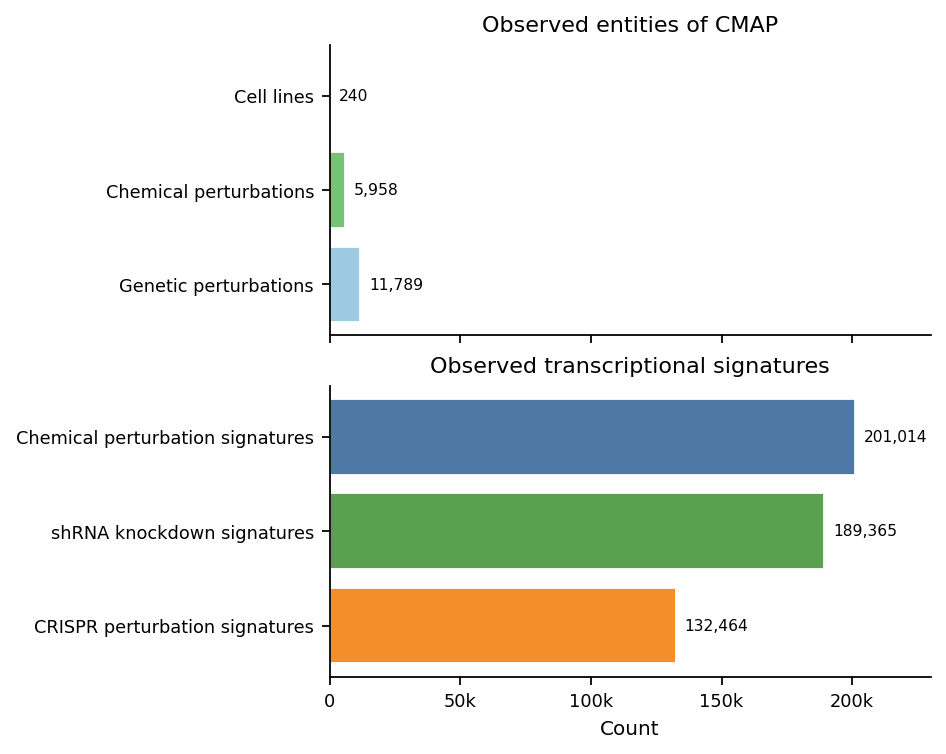

/Users/dudu/Documents/3_Project/12_PxFquery/5_phase_translation/G-011_paper_figure_planning/T-145_figure2_data_and_notebook_figure_workbench/4_artifact/4_picture/figure2/figure2_panel_A_resource_scale.png
/Users/dudu/Documents/3_Project/12_PxFquery/5_phase_translation/G-011_paper_figure_planning/T-145_figure2_data_and_notebook_figure_workbench/4_artifact/4_picture/figure2/figure2_panel_A_resource_scale.svg
/Users/dudu/Documents/3_Project/12_PxFquery/5_phase_translation/G-011_paper_figure_planning/T-145_figure2_data_and_notebook_figure_workbench/4_artifact/4_picture/figure2/figure2_panel_A_resource_scale.pdf


In [3]:
from matplotlib.ticker import FuncFormatter

genetic_perturbations = set(load_obs('sh')['cmap_name'].dropna().astype(str)) | set(load_obs('xpr')['cmap_name'].dropna().astype(str))

reference_summary = pd.DataFrame({
    'category': [
        'Cell lines',
        'Chemical perturbations',
        'Genetic perturbations',
    ],
    'count': [
        len(cell_index.get('valid_cells', [])),
        len(drug_index),
        len(genetic_perturbations),
    ],
    'group': 'Queryable entity size',
})

signature_summary = pd.DataFrame({
    'category': [
        'Chemical perturbation signatures',
        'shRNA knockdown signatures',
        'CRISPR perturbation signatures',
    ],
    'count': [
        int(scale.loc[scale.modality=='cp','n_obs_rows'].iloc[0]),
        int(scale.loc[scale.modality=='sh','n_obs_rows'].iloc[0]),
        int(scale.loc[scale.modality=='xpr','n_obs_rows'].iloc[0]),
    ],
    'group': 'Observed assay matrix size',
})

summary = pd.concat([reference_summary, signature_summary], ignore_index=True)
summary.to_csv(TABLE_DIR / 'figure2_table_panel_A_summary_counts.csv', index=False)

fig, axes = plt.subplots(2, 1, figsize=(5.8, 4.6), sharex=True, constrained_layout=True)
palettes = [('#9ECAE1', '#74C476', '#BDA0CB'), ('#F28E2B', '#59A14F', '#4E79A7')]
shared_xlim = (0, 230_000)
major_ticks = [0, 50_000, 100_000, 150_000, 200_000]
count_formatter = FuncFormatter(lambda x, pos: '0' if x == 0 else f'{int(x/1000)}k')

for ax, data, title, colors in zip(
    axes,
    [reference_summary, signature_summary],
    ['Observed entities of CMAP', 'Observed transcriptional signatures'],
    palettes,
):
    plot_data = data.iloc[::-1].reset_index(drop=True)
    ax.barh(plot_data['category'], plot_data['count'], color=colors[:len(plot_data)], edgecolor='white', linewidth=0.8)
    ax.set_xlim(shared_xlim)
    ax.set_xticks(major_ticks)
    ax.xaxis.set_major_formatter(count_formatter)
    ax.set_title(title, fontsize=10, pad=6)
    ax.tick_params(axis='y', labelsize=8)
    ax.tick_params(axis='x', labelsize=8)
    for y, value in enumerate(plot_data['count']):
        ax.text(value + shared_xlim[1] * 0.015, y, f'{value:,}', va='center', ha='left', fontsize=7)
    ax.spines[['top','right']].set_visible(False)

axes[-1].set_xlabel('Count')
fig.suptitle('', fontsize=11, y=1.03)
paths = save_figure(fig, 'figure2_panel_A_resource_scale')
plt.show()
print('\n'.join(map(str, paths)))

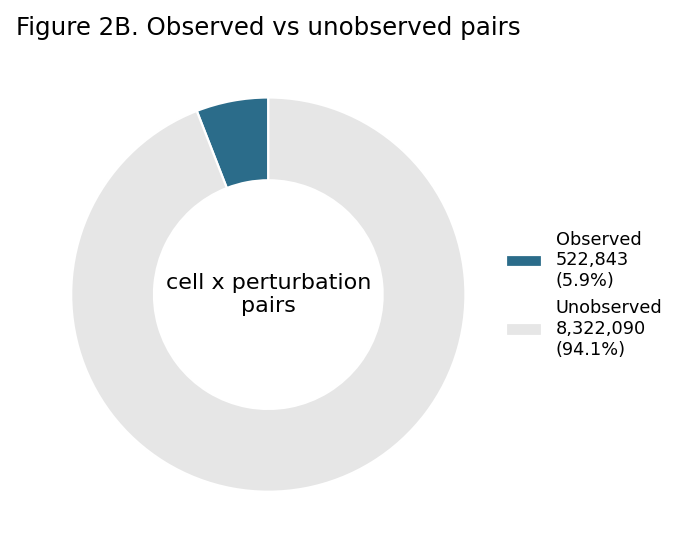

/Users/dudu/Documents/3_Project/12_PxFquery/5_phase_translation/G-011_paper_figure_planning/T-145_figure2_data_and_notebook_figure_workbench/4_artifact/4_picture/figure2/figure2_panel_B_observed_unobserved_donut.png
/Users/dudu/Documents/3_Project/12_PxFquery/5_phase_translation/G-011_paper_figure_planning/T-145_figure2_data_and_notebook_figure_workbench/4_artifact/4_picture/figure2/figure2_panel_B_observed_unobserved_donut.svg
/Users/dudu/Documents/3_Project/12_PxFquery/5_phase_translation/G-011_paper_figure_planning/T-145_figure2_data_and_notebook_figure_workbench/4_artifact/4_picture/figure2/figure2_panel_B_observed_unobserved_donut.pdf


In [3]:

plot_row = summary_all[summary_all['modality']=='total_by_modality_sum'].iloc[0]
values = [plot_row['observed_pairs'], plot_row['unobserved_pairs']]
labels = [f"Observed\n{int(values[0]):,}\n({values[0]/sum(values):.1%})", f"Unobserved\n{int(values[1]):,}\n({values[1]/sum(values):.1%})"]
fig, ax = plt.subplots(figsize=(4.6, 4.0))
wedges, _ = ax.pie(values, startangle=90, colors=['#2B6C8A', '#E6E6E6'], wedgeprops={'width':0.42, 'edgecolor':'white'})
ax.text(0, 0, 'cell x perturbation\npairs', ha='center', va='center', fontsize=10)
ax.legend(wedges, labels, loc='center left', bbox_to_anchor=(0.95, 0.5), frameon=False, fontsize=8)
ax.set_title('Figure 2B. Observed vs unobserved pairs')
paths = save_figure(fig, 'figure2_panel_B_observed_unobserved_donut')
plt.show()
print('\n'.join(map(str, paths)))


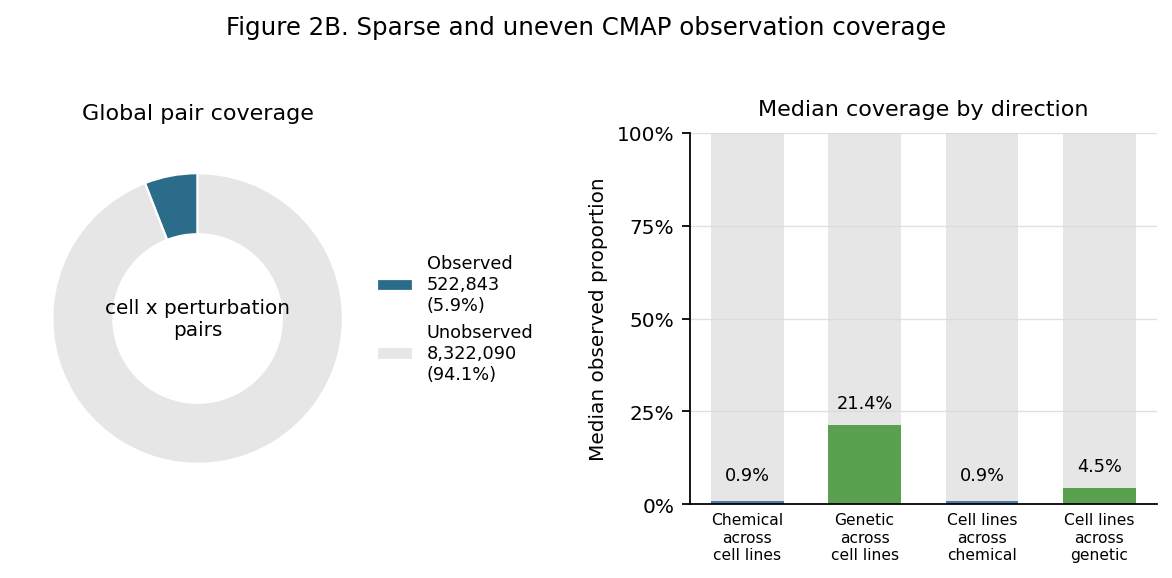

                          label    median      n
0  Chemical\nacross\ncell lines  0.008734  33605
1   Genetic\nacross\ncell lines  0.214286  11789
2  Cell lines\nacross\nchemical  0.009493    229
3   Cell lines\nacross\ngenetic  0.045042     42
/Users/dudu/Documents/3_Project/12_PxFquery/5_phase_translation/G-011_paper_figure_planning/T-145_figure2_data_and_notebook_figure_workbench/4_artifact/4_picture/figure2/figure2_panel_B_combined_observed_unobserved_and_median_coverage.png
/Users/dudu/Documents/3_Project/12_PxFquery/5_phase_translation/G-011_paper_figure_planning/T-145_figure2_data_and_notebook_figure_workbench/4_artifact/4_picture/figure2/figure2_panel_B_combined_observed_unobserved_and_median_coverage.svg
/Users/dudu/Documents/3_Project/12_PxFquery/5_phase_translation/G-011_paper_figure_planning/T-145_figure2_data_and_notebook_figure_workbench/4_artifact/4_picture/figure2/figure2_panel_B_combined_observed_unobserved_and_median_coverage.pdf


In [5]:
from matplotlib.ticker import PercentFormatter

plot_row = summary_all[summary_all['modality']=='total_by_modality_sum'].iloc[0]
donut_values = [plot_row['observed_pairs'], plot_row['unobserved_pairs']]
donut_labels = [
    f"Observed\n{int(donut_values[0]):,}\n({donut_values[0]/sum(donut_values):.1%})",
    f"Unobserved\n{int(donut_values[1]):,}\n({donut_values[1]/sum(donut_values):.1%})",
]

kde_summary = pd.read_csv(TABLE_DIR / 'figure2_appendix2_kde_coverage_distribution_summary.csv')
bar_order = [
    ('Chemical perturbations', 'Across cell lines', 'Chemical\nacross\ncell lines'),
    ('Genetic perturbations', 'Across cell lines', 'Genetic\nacross\ncell lines'),
    ('Chemical perturbations', 'Across perturbations', 'Cell lines\nacross\nchemical'),
    ('Genetic perturbations', 'Across perturbations', 'Cell lines\nacross\ngenetic'),
]
bar_rows = []
for cls, direction, label in bar_order:
    row = kde_summary[(kde_summary['class'] == cls) & (kde_summary['direction'] == direction)].iloc[0]
    bar_rows.append({'label': label, 'median': float(row['median']), 'n': int(row['n'])})
bar_df = pd.DataFrame(bar_rows)
bar_df.to_csv(TABLE_DIR / 'figure2_panel_B_median_coverage_summary.csv', index=False)

fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(7.4, 3.45), gridspec_kw={'width_ratios': [1.05, 1.35]})
wedges, _ = ax0.pie(
    donut_values,
    startangle=90,
    colors=['#2B6C8A', '#E6E6E6'],
    wedgeprops={'width': 0.42, 'edgecolor': 'white'},
)
ax0.text(0, 0, 'cell x perturbation\npairs', ha='center', va='center', fontsize=9)
ax0.legend(wedges, donut_labels, loc='center left', bbox_to_anchor=(0.95, 0.5), frameon=False, fontsize=8)
ax0.set_title('Global pair coverage', fontsize=10, pad=8)

x = np.arange(len(bar_df))
colors = ['#4E79A7', '#59A14F', '#4E79A7', '#59A14F']
ax1.bar(x, np.ones(len(bar_df)), width=0.62, color='#E6E6E6', edgecolor='none', zorder=1)
ax1.bar(x, bar_df['median'], width=0.62, color=colors, edgecolor='none', zorder=2)
for xi, value in zip(x, bar_df['median']):
    ax1.text(xi, max(value + 0.035, 0.055), f'{value:.1%}', ha='center', va='bottom', fontsize=8)
ax1.set_ylim(0, 1.0)
ax1.set_yticks([0, 0.25, 0.5, 0.75, 1.0])
ax1.yaxis.set_major_formatter(PercentFormatter(1.0, decimals=0))
ax1.set_ylabel('Median observed proportion')
ax1.set_xticks(x)
ax1.set_xticklabels(bar_df['label'], fontsize=7)
ax1.set_title('Median coverage by direction', fontsize=10, pad=8)
ax1.spines[['top', 'right']].set_visible(False)
ax1.grid(axis='y', color='#D9D9D9', linewidth=0.6, alpha=0.8, zorder=0)
ax1.tick_params(axis='x', length=0)

fig.suptitle('Figure 2B. Sparse and uneven CMAP observation coverage', fontsize=11, y=1.03)
fig.tight_layout(w_pad=2.4)
paths = save_figure(fig, 'figure2_panel_B_combined_observed_unobserved_and_median_coverage')
plt.show()
print(bar_df)
print('\n'.join(map(str, paths)))

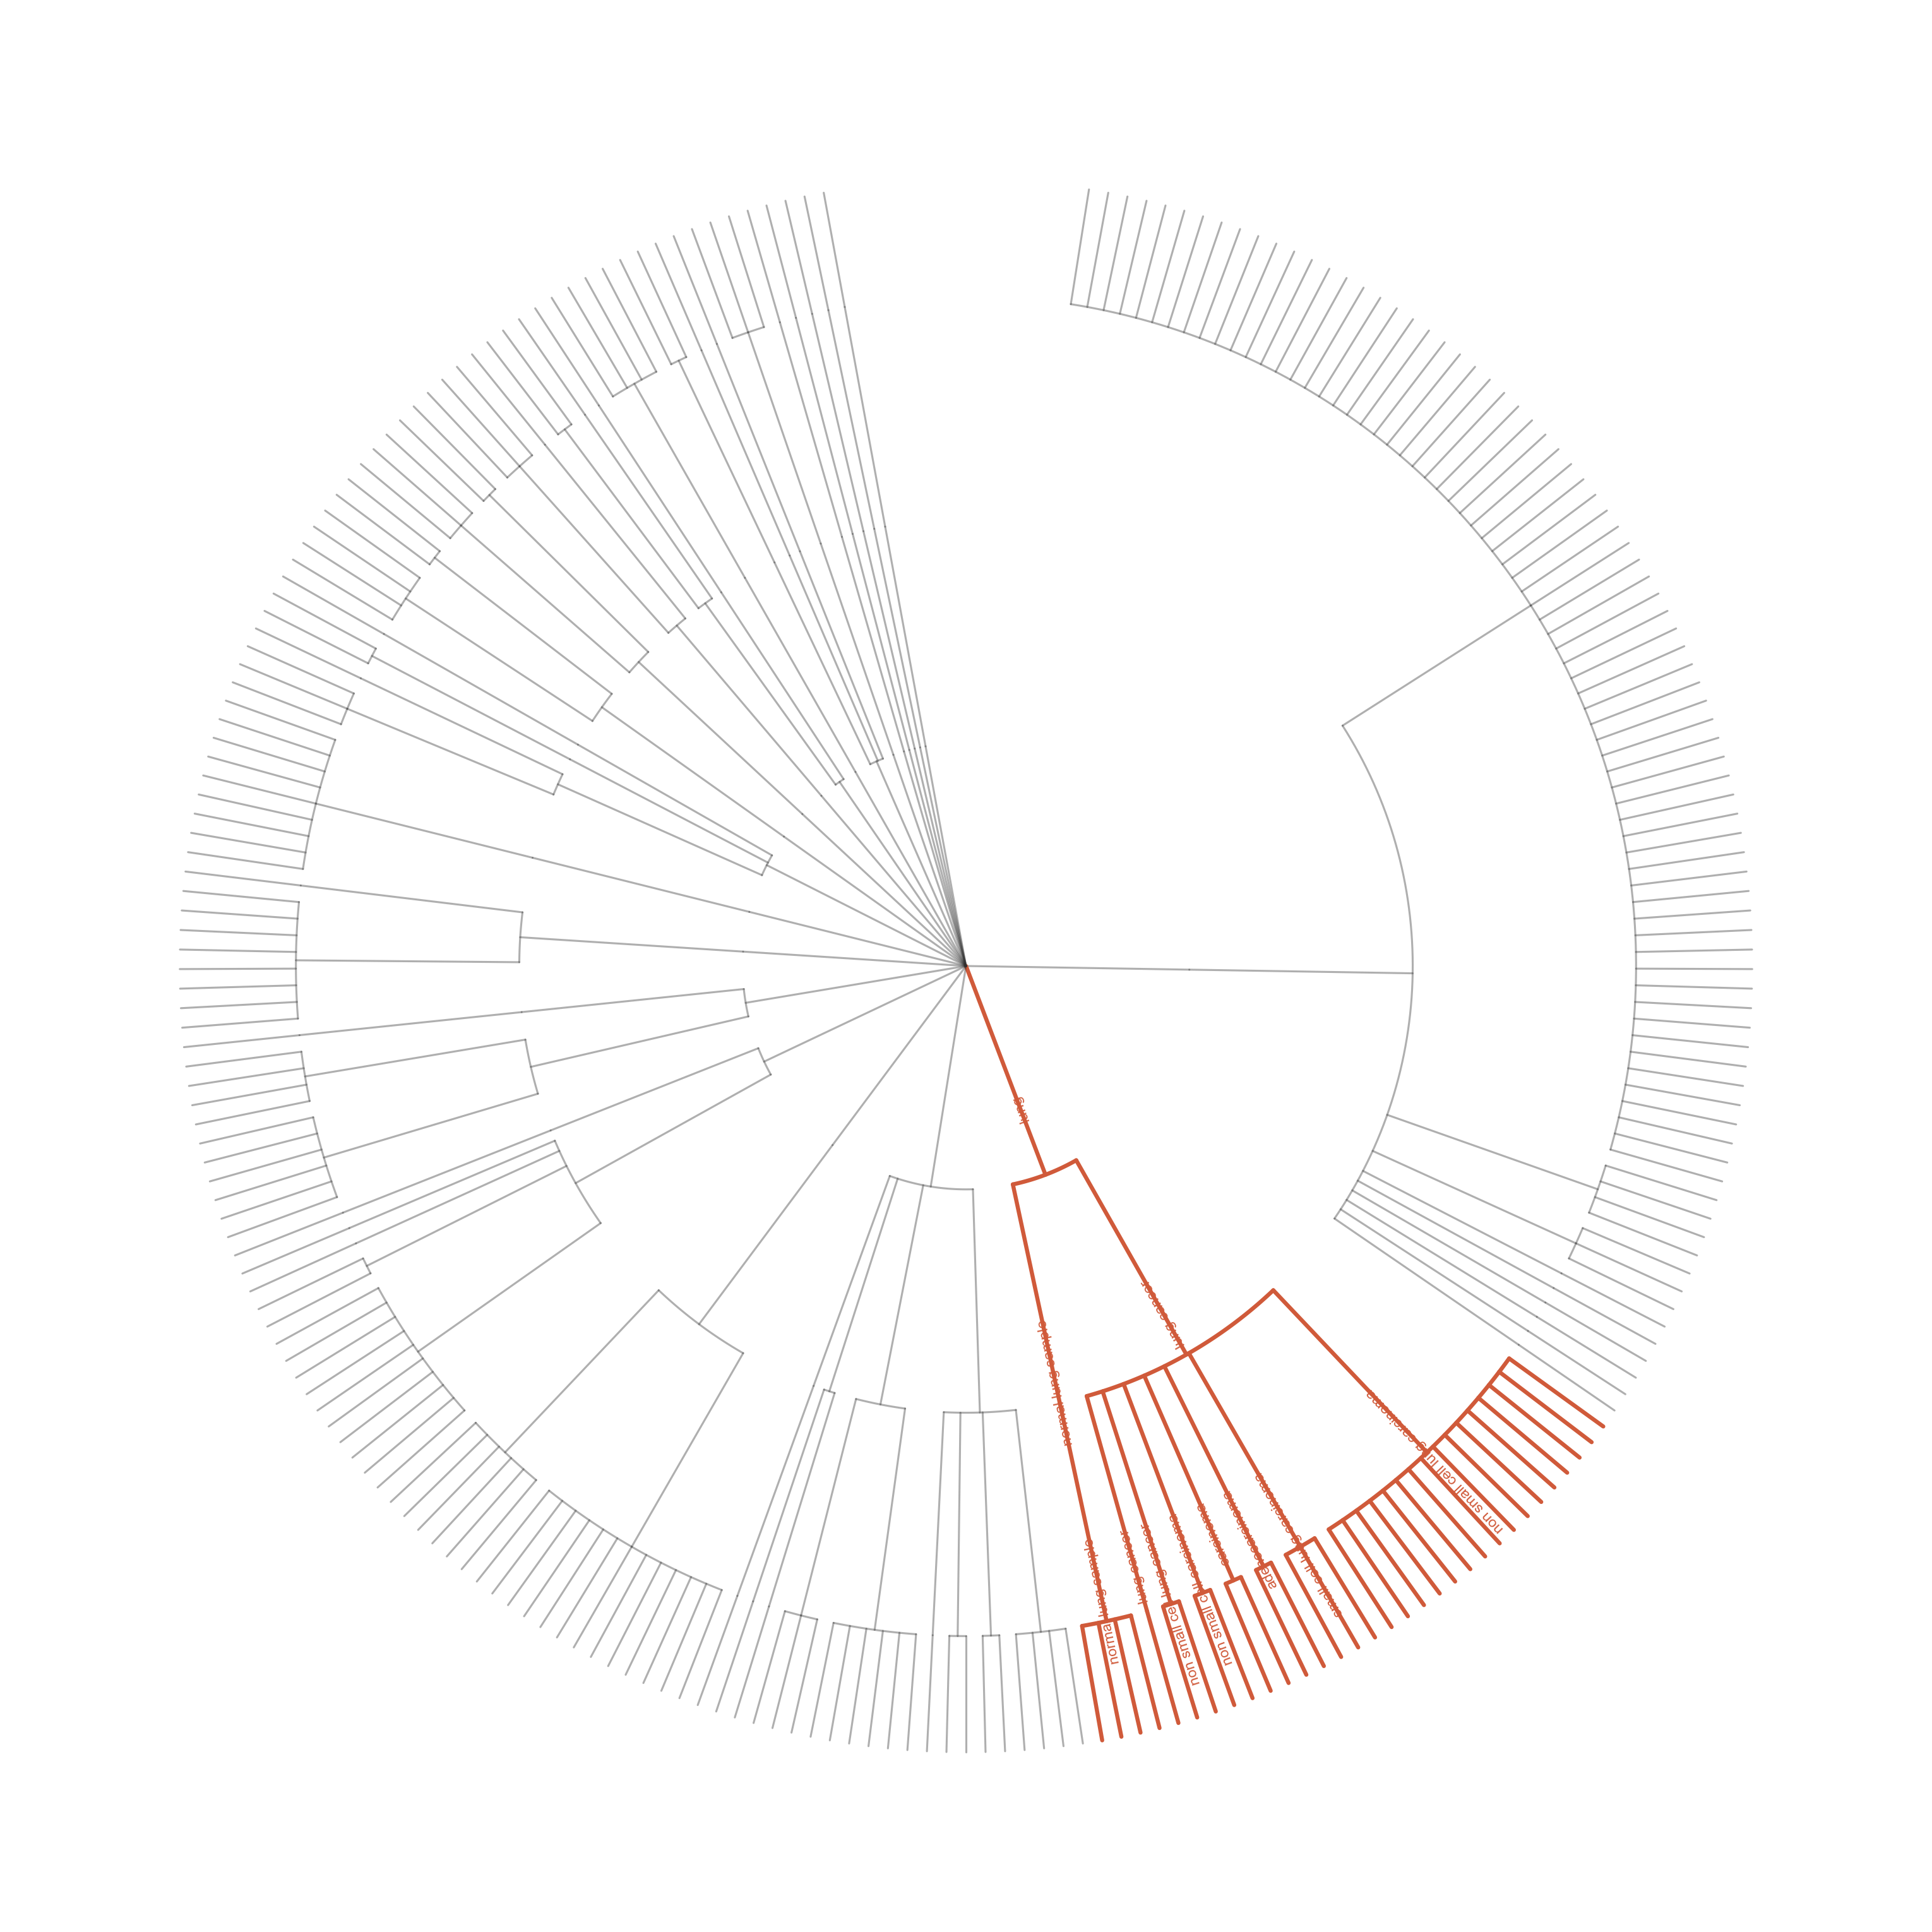

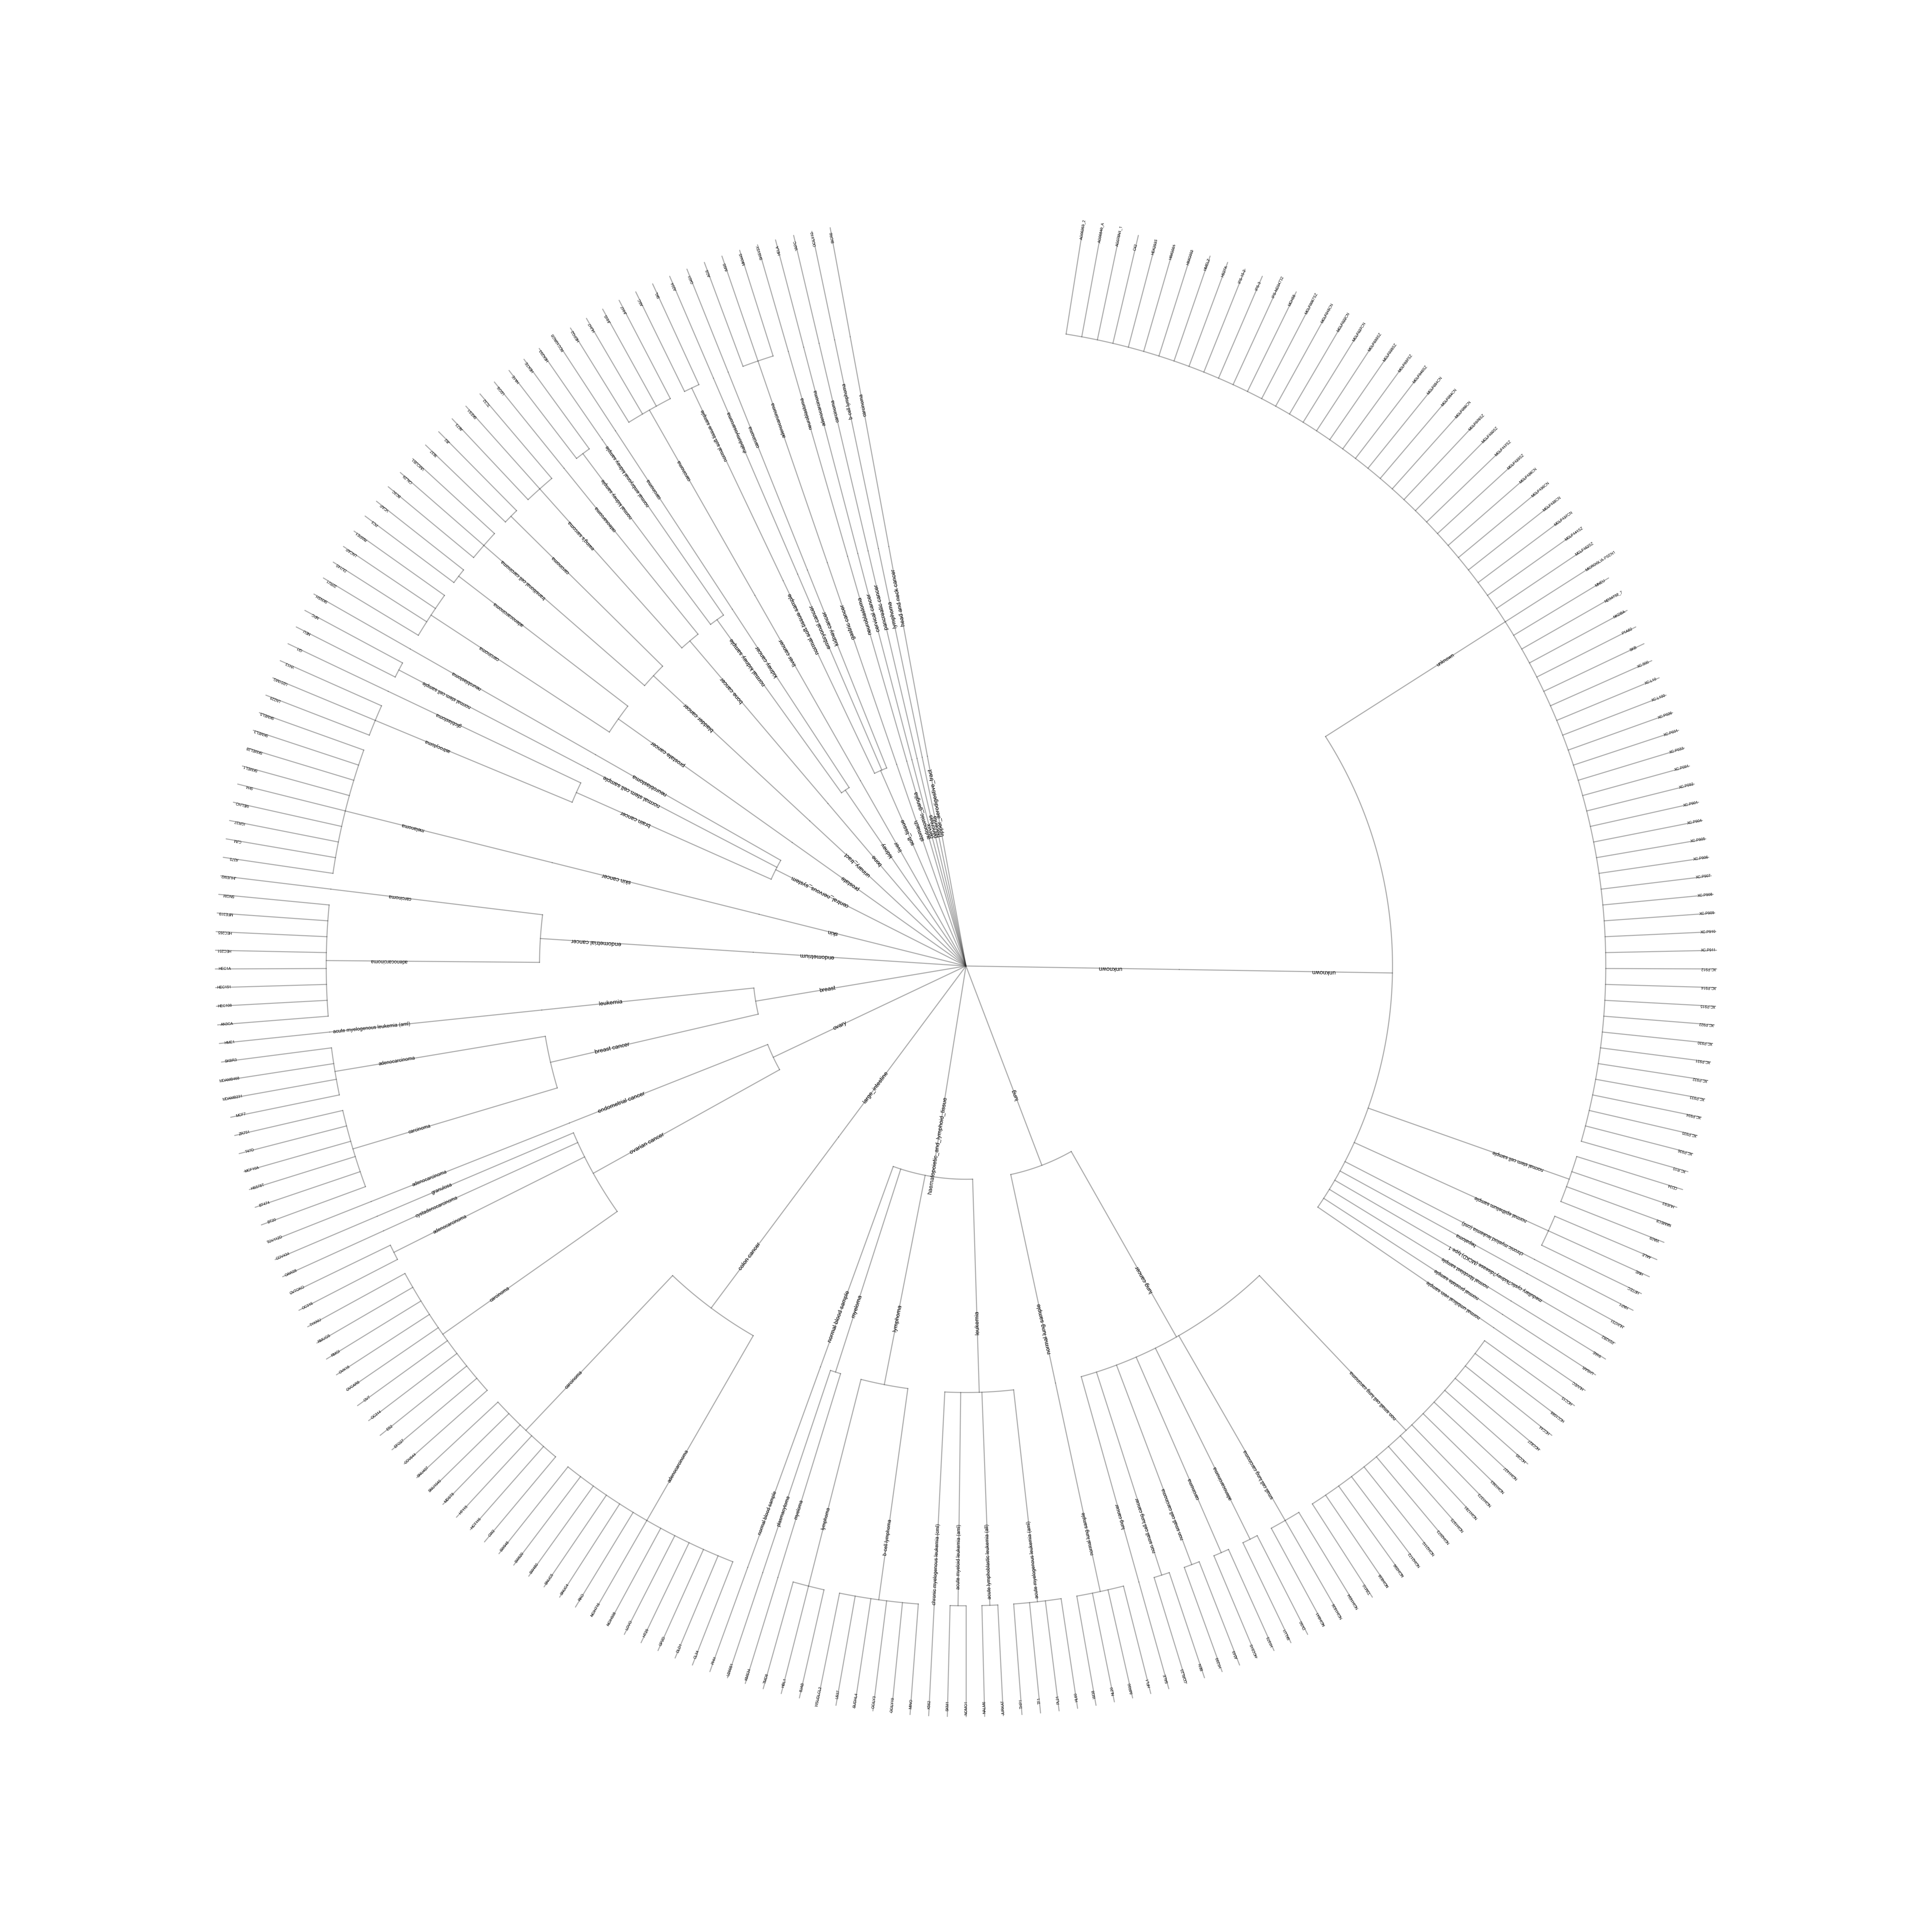

In [2]:
from IPython.display import Image, display
display(Image(filename=str(PIC / "figure2_panel_C_cellline_routing_tree_circular.png")))
display(Image(filename=str(PIC / "figure2_appendix_full_cellline_routing_tree_labeled.png")))